**Team: Abren V Gigimon, Shubh Harde Kamesh**

In [ ]:
import os
import pandas as pd
import json


from pprint import pprint

base_path = "/raw_data/hasyimabdillah/workoutfitness-video"

def load_bdd_files(base_path):
    bdd_structure = {}
    for cls in ["barbell biceps curl", "bench press", "deadlift","plank", "pull up", "push-up", "shoulder press","squat"]:
        cls_path = os.path.join(base_path, cls)
        if os.path.isdir(cls_path):
            vids = [f for f in os.listdir(cls_path)
                    if os.path.isfile(os.path.join(cls_path, f))]
            bdd_structure[cls] = vids
    return bdd_structure

pprint(load_bdd_files(base_path))

{'barbell biceps curl': ['barbell biceps curl_61.mp4',
                         'barbell biceps curl_11.mp4',
                         'barbell biceps curl_18.mp4',
                         'barbell biceps curl_31.mp4',
                         'barbell biceps curl_45.mp4',
                         'barbell biceps curl_32.mp4',
                         'barbell biceps curl_49.mp4',
                         'barbell biceps curl_30.mp4',
                         'barbell biceps curl_56.mp4',
                         'barbell biceps curl_36.mp4',
                         'barbell biceps curl_2.mp4',
                         'barbell biceps curl_44.mp4',
                         'barbell biceps curl_40.mp4',
                         'barbell biceps curl_16.mp4',
                         'barbell biceps curl_7.mp4',
                         'barbell biceps curl_37.mp4',
                         'barbell biceps curl_20.mp4',
                         'barbell biceps curl_21.mp4',
            

Build Dataframe

In [4]:
import json

def buildtrial(base_path):
    rows = []

    for cls in ["barbell biceps curl", "bench press", "deadlift","plank", "pull up", "push-up", "shoulder press","squat"]:
        cls_path = os.path.join(base_path, cls)
        if not os.path.isdir(cls_path):
            continue

        vid_path=None
        for f in os.listdir(cls_path):
            vid_path = os.path.join(cls_path, f)
            if os.path.isfile(vid_path):
                rows.append({"vid_path": vid_path, "class": cls})
            
    return pd.DataFrame(rows)


index_df = buildtrial(base_path)
index_df

,vid_path,class
0,/kaggle/input/datasets/hasyimabdillah/workoutf...,barbell biceps curl
1,/kaggle/input/datasets/hasyimabdillah/workoutf...,barbell biceps curl
2,/kaggle/input/datasets/hasyimabdillah/workoutf...,barbell biceps curl
3,/kaggle/input/datasets/hasyimabdillah/workoutf...,barbell biceps curl
4,/kaggle/input/datasets/hasyimabdillah/workoutf...,barbell biceps curl
...,...,...
259,/kaggle/input/datasets/hasyimabdillah/workoutf...,squat
260,/kaggle/input/datasets/hasyimabdillah/workoutf...,squat
261,/kaggle/input/datasets/hasyimabdillah/workoutf...,squat
262,/kaggle/input/datasets/hasyimabdillah/workoutf...,squat


The dataset consists of video files categorized into eight specific workout activities: barbell biceps curl, bench press, deadlift, plank, pull up, push-up, shoulder press, and squat. The initial preprocessing involves walking through the directory structure to map each video path to its corresponding class label. A master index is created as a Pandas DataFrame to facilitate organized processing. The dataset is moderately balanced, though some classes like "plank" have significantly fewer samples than others like "push-up" or "bench press," necessitating the use of class weights during model training to ensure the classifier does not become biased toward the more frequent exercises.

Keypoint Extraction using Movenet

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

# MoveNet Lightning 
movenet = hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
model = movenet.signatures["serving_default"]

I0000 00:00:1773321134.613386      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773321134.616235      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
import cv2
import numpy as np



KEYPOINT_DICT = {
    "nose": 0, "left_eye": 1, "right_eye": 2, "left_ear": 3, "right_ear": 4,
    "left_shoulder": 5, "right_shoulder": 6, "left_elbow": 7, "right_elbow": 8,
    "left_wrist": 9, "right_wrist": 10, "left_hip": 11, "right_hip": 12,
    "left_knee": 13, "right_knee": 14, "left_ankle": 15, "right_ankle": 16
}


IMG_SIZE = 192
NUM_KPTS = 17

def movenet_frame(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_resized = tf.image.resize_with_pad(tf.expand_dims(frame_rgb, axis=0), IMG_SIZE, IMG_SIZE)
    frame_tensor = tf.cast(frame_resized, tf.int32)

    outputs = model(frame_tensor)
    kpts = outputs["output_0"].numpy()          # (1,1,17,3)
    kpts = np.squeeze(kpts, axis=(0,1))         # (17,3)
    return kpts

In [ ]:
def sample_indices(num_frames, T):
    return np.linspace(0, max(num_frames - 1, 0), T).astype(int)  

def keypoints(video_path, T=30):
    cap = cv2.VideoCapture(video_path)
    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if num_frames <= 0:
        cap.release()
        return None

    idxs = sample_indices(num_frames, T)
    seq = np.zeros((T, NUM_KPTS, 3), dtype=np.float32)

    last_valid = None
    for i, idx in enumerate(idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            
            if last_valid is not None:
                seq[i] = last_valid
            continue

        kpts = movenet_frame(frame)
        seq[i] = kpts
        last_valid = kpts

    cap.release()
    return seq

In [ ]:
def normalize_kpts(seq):  
    # seq: (T,17,3) 
    xy = seq[..., :2]     # (T,17,2)
    sc = seq[..., 2:3]    # (T,17,1)

    lh, rh = KEYPOINT_DICT["left_hip"], KEYPOINT_DICT["right_hip"]
    ls, rs = KEYPOINT_DICT["left_shoulder"], KEYPOINT_DICT["right_shoulder"]

    hip_center = (xy[:, lh] + xy[:, rh]) / 2.0                         # (T,2)
    shoulder_dist = np.linalg.norm(xy[:, ls] - xy[:, rs], axis=-1)      # (T,)
    shoulder_dist = shoulder_dist.reshape(-1, 1) + 1e-6                 # (T,1)

    xy_norm = (xy - hip_center[:, None, :]) / shoulder_dist[:, None, :] # (T,17,2)
    return np.concatenate([xy_norm, sc], axis=-1).astype(np.float32)    # (T,17,3)

For the first stage of the project, MoveNet Lightning was selected as the pre-trained model for pose estimation. MoveNet was chosen for its balance of speed and accuracy, specifically its ability to produce 17 body keypoints in real-time. The preprocessing pipeline for this model involves resizing each video frame to a 192x192 tensor. To handle the temporal nature of the videos while maintaining computational efficiency, a sampling strategy was implemented to extract exactly 30 frames per video using linear spacing.

A critical preprocessing step performed here is Keypoint Normalization. The raw $(y, x)$ coordinates are centered based on the midpoint of the hips and scaled by the distance between the shoulders. This ensures that the model is invariant to the person's position in the frame or their distance from the camera, focusing strictly on the relative posture. The final input for the training model is a flattened sequence of these normalized coordinates and their confidence scores.

In [ ]:
import os
from tqdm import tqdm

OUT_DIR = "processed_data/kpts"
os.makedirs(OUT_DIR, exist_ok=True)

classes = sorted(index_df["class"].unique())
class_to_id = {c:i for i,c in enumerate(classes)}

T = 30
rows_out = []
bad = 0

for i, row in tqdm(index_df.iterrows(), total=len(index_df)):
    vp = row["vid_path"]
    cls = row["class"]
    y = class_to_id[cls]

    seq = keypoints(vp, T=T)
    if seq is None:
        bad += 1
        continue

    seq = normalize_kpts(seq)

    save_path = os.path.join(OUT_DIR, f"kpts_{i:06d}.npy")
    np.save(save_path, seq)

    rows_out.append({"kpts_path": save_path, "label": y, "class": cls})

kpts_df = pd.DataFrame(rows_out)
print("Saved:", len(kpts_df), "Bad videos:", bad)
kpts_df.head()

100%|██████████| 264/264 [12:17<00:00,  2.79s/it]

Saved: 264 Bad videos: 0


,kpts_path,label,class
0,/kaggle/working/kpts/kpts_000000.npy,0,barbell biceps curl
1,/kaggle/working/kpts/kpts_000001.npy,0,barbell biceps curl
2,/kaggle/working/kpts/kpts_000002.npy,0,barbell biceps curl
3,/kaggle/working/kpts/kpts_000003.npy,0,barbell biceps curl
4,/kaggle/working/kpts/kpts_000004.npy,0,barbell biceps curl


In [ ]:
def load_Xy(kpts_df):
    X_list = []
    y_list = []
    for _, r in kpts_df.iterrows():
        seq = np.load(r["kpts_path"])              # (T,17,3)
        X_list.append(seq.reshape(T, -1))          # (T,51)
        y_list.append(r["label"])
    X = np.stack(X_list).astype(np.float32)        
    y = np.array(y_list, dtype=np.int32)
    return X, y

X, y = load_Xy(kpts_df)
print(X.shape, y.shape)

(264, 30, 51) (264,)


Model Building and Training

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(classes)
def create_model():
    

    model1 = keras.Sequential([
    layers.Input(shape=(T, X.shape[-1])),   
    layers.Conv1D(128, 5, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPool1D(2),
    layers.Conv1D(256, 5, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])
    return model1
    
model1 = create_model()

model1.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 128)        │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,199 (907.03 KB)

 Trainable params: 231,431 (904.03 KB)

 Non-trainable params: 768 (3.00 KB)

The hyperparameters for the Conv1D model were selected to balance the need for capturing complex temporal patterns with the requirement for stable training on a relatively small dataset. Key choices include:

Filter Sizes (128 and 256): Larger filter counts allow the model to learn a wide variety of spatial and temporal features from the normalized keypoint sequences.

Kernel Size (5): A kernel size of 5 was chosen to look at a small window of frames at once, effectively capturing short-term movement trends like the beginning of a lift or a descent.

Dropout (0.3): A dropout rate of 30% was applied to the dense layer to mitigate overfitting, ensuring the model generalizes well to new video data rather than memorizing the training set.

Batch Size (4): Given the dataset size, a small batch size was used to provide more frequent weight updates, which often helps in finding a more stable local minimum during the optimization process.

Learning Rate Schedule: The use of ReduceLROnPlateau allows the model to "slow down" its learning once the loss plateaus, preventing the optimizer from overshooting the optimal weights as it approaches convergence.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)



counts = np.bincount(y_train)
class_weights = 1.0 / np.maximum(counts, 1)

print("Class counts:", counts)
print("Class weights:", class_weights)

class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}



Class counts: [49 49 25  6 45 14 23]
Class weights: [0.02040816 0.02040816 0.04       0.16666667 0.02222222 0.07142857
 0.04347826]


In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model1.fit(X_train, y_train,validation_data=(X_val, y_val), epochs=40, batch_size=4,class_weight=class_weight_dict,callbacks=callbacks
)

Epoch 1/40


I0000 00:00:1773321883.920995     128 service.cc:152] XLA service 0x7d47a802e5e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773321883.921048     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773321883.921056     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


42/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2576 - loss: 0.0700

I0000 00:00:1773321886.635792     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.2672 - loss: 0.0692 - val_accuracy: 0.5849 - val_loss: 1.6694 - learning_rate: 0.0010
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6203 - loss: 0.0432 - val_accuracy: 0.5849 - val_loss: 1.4033 - learning_rate: 0.0010
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5271 - loss: 0.0370 - val_accuracy: 0.6415 - val_loss: 0.9947 - learning_rate: 0.0010
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5590 - loss: 0.0403 - val_accuracy: 0.7358 - val_loss: 1.0459 - learning_rate: 0.0010
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5992 - loss: 0.0316 - val_accuracy: 0.7170 - val_loss: 1.1272 - learning_rate: 0.0010
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7030 - loss: 0.0301 - val_accuracy: 0.6226 - val_loss: 1.1728 - learning_rate: 0.0010
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7331 - loss: 0.0237 - val_accuracy: 0.7170 - v

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd


y_prob = model1.predict(X_val)               
y_pred = np.argmax(y_prob, axis=1)         


id_to_class = {i: c for c, i in class_to_id.items()}

y_true_names = [id_to_class[i] for i in y_val]
y_pred_names = [id_to_class[i] for i in y_pred]


pred_df = pd.DataFrame({
    "True Label": y_true_names,
    "Predicted Label": y_pred_names
})

print(pred_df.head(20))

#  Classification report 
print("\nClassification Report:\n")
print(classification_report(
    y_val,
    y_pred,
    target_names=[id_to_class[i] for i in range(len(id_to_class))]
))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{id_to_class[i]}" for i in range(len(id_to_class))],
    columns=[f"Pred_{id_to_class[i]}" for i in range(len(id_to_class))]
)

print("\nConfusion Matrix:\n")
print(cm_df)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
             True Label      Predicted Label
0           bench press  barbell biceps curl
1        shoulder press       shoulder press
2   barbell biceps curl  barbell biceps curl
3              deadlift             deadlift
4   barbell biceps curl  barbell biceps curl
5              deadlift             deadlift
6               push-up              push-up
7   barbell biceps curl  barbell biceps curl
8           bench press          bench press
9   barbell biceps curl  barbell biceps curl
10          bench press          bench press
11          bench press          bench press
12  barbell biceps curl  barbell biceps curl
13              push-up              push-up
14  barbell biceps curl  barbell biceps curl
15              push-up              push-up
16          bench press          bench press
17                squat                squat
18       shoulder press       shoulder press
19              push-up              push-up

Classification 

In [15]:
	
model_evaluation_history = model1.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 437ms/step - accuracy: 0.8703 - loss: 0.7298


In [ ]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
 
  metric_value_1 = history.history[metric_name_1]
  metric_value_2 = history.history[metric_name_2]
  epochs = range(len(metric_value_1))
   
 
  plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
  plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)
  plt.title(str(plot_name))
  plt.legend()

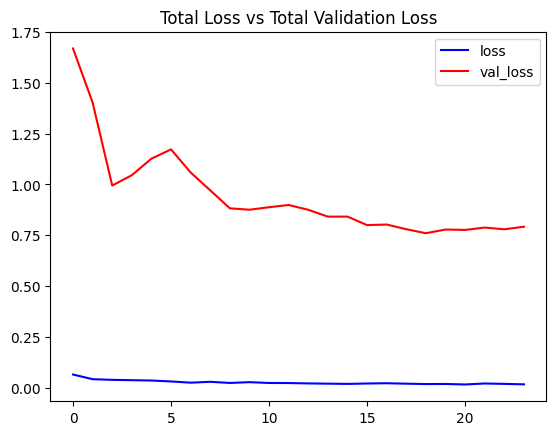

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
plot_metric('loss', 'val_loss', 'Total Loss vs Total Validation Loss')

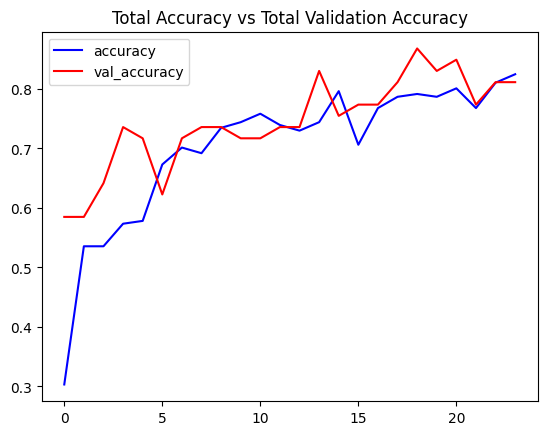

In [18]:
plot_metric('accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

The keypoint-based classifier utilizes a 1D Convolutional Neural Network (Conv1D). This architecture is effective for this task because it can extract temporal patterns from the sequence of body movements. The model achieved an overall accuracy of 87% on the validation set. Looking at the classification report, the model performs exceptionally well on "plank" and "push-up" (1.00 F1-score), likely because these movements have very distinct, static, or repetitive geometric signatures. The "squat" category showed the lowest precision (0.56), often being confused with "barbell biceps curls" or "shoulder presses" in certain frames where the vertical movement of the body is similar.

Task 2: Feature Engineering

In [19]:
KEYPOINT_DICT = {
    "nose": 0, "left_eye": 1, "right_eye": 2, "left_ear": 3, "right_ear": 4,
    "left_shoulder": 5, "right_shoulder": 6, "left_elbow": 7, "right_elbow": 8,
    "left_wrist": 9, "right_wrist": 10, "left_hip": 11, "right_hip": 12,
    "left_knee": 13, "right_knee": 14, "left_ankle": 15, "right_ankle": 16
}

In [20]:
import numpy as np
import pandas as pd

def xy(kpt):
    y = kpt[..., 0]
    x = kpt[..., 1]
    return x, y

In [21]:
def angle(a, b, c):
    ba = a - b
    bc = c - b

    dot = np.sum(ba * bc, axis=1)
    norm_ba = np.linalg.norm(ba, axis=1)
    norm_bc = np.linalg.norm(bc, axis=1)

    cosang = dot / (norm_ba * norm_bc + 1e-8)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang = np.degrees(np.arccos(cosang))
    return ang

In [ ]:
def distance(a, b):
    return np.linalg.norm(a - b, axis=1)

def angular_vel(angle_seq):
    return np.diff(angle_seq, prepend=angle_seq[0])

def rom(angle_seq):
    return np.max(angle_seq) - np.min(angle_seq)

In [ ]:
def extract_framewise_features(kpt):
   
    x, y = xy(kpt)
    def pt(idx):
        return np.stack([x[:, idx], y[:, idx]], axis=1)

    ls = pt(KEYPOINT_DICT["left_shoulder"])
    rs = pt(KEYPOINT_DICT["right_shoulder"])
    le = pt(KEYPOINT_DICT["left_elbow"])
    re = pt(KEYPOINT_DICT["right_elbow"])
    lw = pt(KEYPOINT_DICT["left_wrist"])
    rw = pt(KEYPOINT_DICT["right_wrist"])
    lh = pt(KEYPOINT_DICT["left_hip"])
    rh = pt(KEYPOINT_DICT["right_hip"])
    lk = pt(KEYPOINT_DICT["left_knee"])
    rk = pt(KEYPOINT_DICT["right_knee"])
    la = pt(KEYPOINT_DICT["left_ankle"])
    ra = pt(KEYPOINT_DICT["right_ankle"])

    #Midpoints
    shoulder_mid = (ls + rs) / 2.0
    hip_mid = (lh + rh) / 2.0

    features = {}

    #Angle
    features["left_elbow_angle"] = angle(ls, le, lw)
    features["right_elbow_angle"] = angle(rs, re, rw)

    features["left_shoulder_angle"] = angle(le, ls, lh)
    features["right_shoulder_angle"] = angle(re, rs, rh)

    features["left_hip_angle"] = angle(ls, lh, lk)
    features["right_hip_angle"] = angle(rs, rh, rk)

    features["left_knee_angle"] = angle(lh, lk, la)
    features["right_knee_angle"] = angle(rh, rk, ra)

    #Trunk inclination: 
    torso_vec = shoulder_mid - hip_mid
    vertical = np.tile(np.array([[0.0, -1.0]]), (len(torso_vec), 1))

    dot = np.sum(torso_vec * vertical, axis=1)
    norm1 = np.linalg.norm(torso_vec, axis=1)
    norm2 = np.linalg.norm(vertical, axis=1)
    cosang = dot / (norm1 * norm2 + 1e-8)
    cosang = np.clip(cosang, -1.0, 1.0)
    features["trunk_inclination"] = np.degrees(np.arccos(cosang))

    #Distance
    features["left_wrist_shoulder_dist"] = distance(lw, ls)
    features["right_wrist_shoulder_dist"] = distance(rw, rs)

    features["left_hip_ankle_dist"] = distance(lh, la)
    features["right_hip_ankle_dist"] = distance(rh, ra)

    features["shoulder_width"] = distance(ls, rs)

    #Velocity
    for k in ["left_elbow_angle", "right_elbow_angle","left_shoulder_angle", "right_shoulder_angle", "left_hip_angle", "right_hip_angle","left_knee_angle", "right_knee_angle","trunk_inclination"]:
        features[k + "vel"] = angular_vel(features[k])

    return features

In [ ]:
def summarize_feature(arr, name):
    arr = np.asarray(arr)
    summary = {
        f"{name}_mean": np.mean(arr),
        f"{name}_std": np.std(arr),
        f"{name}_min": np.min(arr),
        f"{name}_max": np.max(arr),
        f"{name}_median": np.median(arr),
        f"{name}_rom": np.max(arr) - np.min(arr),
        f"{name}_energy": np.mean(arr ** 2),
    }
    return summary

def extract_video_features(kpt):
    f = extract_framewise_features(kpt)
    out = {}
    for name, arr in f.items():
        out.update(summarize_feature(arr, name))
    return out

In [25]:
feature_rows = []

for _, row in kpts_df.iterrows():
    kpt = np.load(row["kpts_path"])   # (T,17,3)

    feats = extract_video_features(kpt)
    feats["label"] = row["label"]
    feats["class"] = row["class"]
    feats["kpts_path"] = row["kpts_path"]

    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
print(features_df.shape)
features_df.head()

(264, 164)


,left_elbow_angle_mean,left_elbow_angle_std,left_elbow_angle_min,left_elbow_angle_max,left_elbow_angle_median,left_elbow_angle_rom,left_elbow_angle_energy,right_elbow_angle_mean,right_elbow_angle_std,right_elbow_angle_min,...,trunk_inclinationvel_mean,trunk_inclinationvel_std,trunk_inclinationvel_min,trunk_inclinationvel_max,trunk_inclinationvel_median,trunk_inclinationvel_rom,trunk_inclinationvel_energy,label,class,kpts_path
0,123.839226,27.707539,63.033291,173.171677,116.133354,110.138382,16103.859375,107.032784,54.077805,7.215424,...,0.115851,2.271932,-4.850969,5.033975,0.128070,9.884944,5.175097,0,barbell biceps curl,/kaggle/working/kpts/kpts_000000.npy
1,126.571678,33.074306,70.789246,179.555878,112.682251,108.766632,17114.294922,129.334457,37.920238,36.209362,...,-0.107123,3.710259,-10.651779,8.897401,-0.107451,19.549180,13.777496,0,barbell biceps curl,/kaggle/working/kpts/kpts_000001.npy
2,104.842804,41.319290,51.934067,166.053345,98.296600,114.119278,12699.296875,110.289307,44.875526,48.959686,...,-0.011351,0.869063,-1.706020,1.691034,-0.076994,3.397055,0.755399,0,barbell biceps curl,/kaggle/working/kpts/kpts_000002.npy
3,98.666710,61.393082,11.877846,179.490631,121.328049,167.612793,13504.229492,115.686165,47.504940,39.823532,...,-0.028032,1.278566,-2.369056,2.994494,-0.076739,5.363550,1.635517,0,barbell biceps curl,/kaggle/working/kpts/kpts_000003.npy
4,145.030807,37.742420,49.158222,180.000000,160.492691,130.841782,22458.429688,132.921646,50.723774,21.705004,...,0.020497,0.895370,-1.893838,1.774409,0.049189,3.668247,0.802108,0,barbell biceps curl,/kaggle/working/kpts/kpts_000004.npy


Model Training

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

feature_cols = [c for c in features_df.columns if c not in ["label", "class", "kpts_path"]]
X_feat = features_df[feature_cols].values
y_feat = features_df["label"].values
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_feat, test_size=0.2, stratify=y_feat, random_state=42
)






rf = RandomForestClassifier(n_estimators=300,max_depth=None,random_state=42,class_weight=class_weight_dict)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=sorted(features_df["class"].unique())))

Accuracy: 0.8490566037735849

Classification Report:

                     precision    recall  f1-score   support

barbell biceps curl       0.86      0.92      0.89        13
        bench press       0.77      0.83      0.80        12
           deadlift       0.83      0.71      0.77         7
              plank       1.00      1.00      1.00         1
            push-up       0.91      0.91      0.91        11
     shoulder press       1.00      1.00      1.00         3
              squat       0.80      0.67      0.73         6

           accuracy                           0.85        53
          macro avg       0.88      0.86      0.87        53
       weighted avg       0.85      0.85      0.85        53



The hyperparameters for the Random Forest model were chosen to maximize the decision-making power of the ensemble while maintaining a high degree of interpretability. The specific settings include:

N_estimators (300): Using 300 individual decision trees ensures that the model's predictions are robust and less sensitive to the specific variances of any single tree.

Max_depth (None): Allowing the trees to grow until all leaves are pure (or contain very few samples) ensures that the model can fully capture the non-linear relationships between joint angles and the specific workout activities.

Class_weight (Balanced): Because the dataset contains a wide disparity in the number of videos per category, the class_weight_dict was applied. This hyperparameter forces the model to treat the misclassification of a rare class (like "plank") as more costly than a more frequent class, leading to the balanced precision and recall seen in the final classification report.

Random_state (42): A fixed seed ensures that the results are reproducible, allowing for consistent evaluation of feature importance and model performance across different runs.

In [27]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(20))

trunk_inclination_energy       0.039175
trunk_inclination_mean         0.036047
trunk_inclination_median       0.027919
right_shoulder_angle_energy    0.025582
left_shoulder_angle_energy     0.024589
right_elbow_angle_energy       0.023564
right_shoulder_angle_std       0.023511
left_elbow_angle_min           0.021226
right_shoulder_angle_mean      0.020742
left_elbow_angle_mean          0.020164
left_shoulder_angle_mean       0.018727
right_shoulder_angle_median    0.018678
trunk_inclination_max          0.018352
right_elbow_angle_mean         0.018226
left_elbow_angle_energy        0.016369
right_shoulder_angle_rom       0.016218
right_elbow_angle_median       0.014482
left_shoulder_angle_std        0.013067
left_shoulder_angle_median     0.012836
left_shoulder_angle_max        0.012538
dtype: float64


To optimize the model and understand the underlying mechanics, feature engineering was performed to convert raw coordinates into biomechanically relevant features. Instead of feeding raw coordinate points, the data was transformed into joint angles (elbows, shoulders, hips, and knees) and trunk inclination. These represent the "minimal set of features" as they describe the actual movement of the human body. Aggregated statisticsincluding mean, standard deviation, and Range of Motion (ROM)were calculated for each video.

The Random Forest analysis identified Trunk Inclination (Energy and Mean) and Shoulder/Elbow Angles as the most significant predictors. For example, Trunk Inclination is a primary differentiator for "deadlifts" and "squats," while Elbow Angles are critical for "biceps curls." Using these engineered features with a Random Forest classifier yielded an accuracy of 85%. This demonstrates that biomechanical features can achieve performance nearly identical to raw keypoints while being significantly more interpretable and computationally lighter.

In [28]:
index_df["label"] = index_df["class"].map(class_to_id)
print(classes)
print(index_df.head())

['barbell biceps curl', 'bench press', 'deadlift', 'plank', 'push-up', 'shoulder press', 'squat']
                                            vid_path                class  \
0  /kaggle/input/datasets/hasyimabdillah/workoutf...  barbell biceps curl   
1  /kaggle/input/datasets/hasyimabdillah/workoutf...  barbell biceps curl   
2  /kaggle/input/datasets/hasyimabdillah/workoutf...  barbell biceps curl   
3  /kaggle/input/datasets/hasyimabdillah/workoutf...  barbell biceps curl   
4  /kaggle/input/datasets/hasyimabdillah/workoutf...  barbell biceps curl   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


MoViNet Classifier

In [ ]:
train_df, temp_df = train_test_split(index_df, test_size=0.3, stratify=index_df["label"], random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)
print(len(train_df), len(val_df), len(test_df))

184 40 40


In [30]:
NUM_FRAMES = 30
IMG_SIZE = 192
BATCH_SIZE = 4
AUTO = tf.data.AUTOTUNE
NUM_CLASSES = len(classes)

In [31]:
def load_video_py(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    video_path = video_path.decode("utf-8")
    cap = cv2.VideoCapture(video_path)

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return np.zeros((num_frames, img_size, img_size, 3), dtype=np.float32)

    indices = np.linspace(0, max(frame_count - 1, 0), num_frames).astype(int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            if frames:
                frame = frames[-1]
            else:
                frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))

        frames.append(frame)

    cap.release()
    frames = np.array(frames, dtype=np.float32) / 255.0
    return frames

In [32]:
def load_video_tf(video_path, label):
    frames = tf.numpy_function(
        load_video_py,
        [video_path],
        tf.float32
    )
    frames.set_shape((NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3))
    return frames, label

In [ ]:
def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["vid_path"].values,
        df["label"].values
    ))

    if training:
        ds = ds.shuffle(len(df), reshuffle_each_iteration=True)

    ds = ds.map(load_video_tf, num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

In [34]:
!pip install -q tf-models-official

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 85.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 38.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [35]:
MOVINET_HANDLE = "https://tfhub.dev/tensorflow/movinet/a0/base/kinetics-600/classification/3"
from official.projects.movinet.modeling import movinet
from official.projects.movinet.modeling import movinet_model

In [ ]:
backbone = movinet.Movinet(model_id='a0',causal=False,conv_type='2plus1d',se_type='2plus3d',activation='hard_swish',gating_activation='hard_sigmoid',
    use_positional_encoding=False,)

In [37]:
model = movinet_model.MovinetClassifier(backbone=backbone,  num_classes=NUM_CLASSES)

In [ ]:
import tf_keras

model.backbone.trainable = False

model.compile( optimizer=tf_keras.optimizers.Adam(1e-3),  loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=False),  metrics=["accuracy"])

callbacks = [
   tf_keras.callbacks.EarlyStopping(   monitor="val_accuracy",   patience=5,restore_best_weights=True),
   tf_keras.callbacks.ReduceLROnPlateau(  monitor="val_loss", factor=0.5,patience=2)]

history_head = model.fit( train_ds,validation_data=val_ds, epochs=10, callbacks=callbacks)

Epoch 1/10
46/46 [==============================] - 467s 9s/step - loss: 2.3306 - accuracy: 0.0163 - val_loss: 1.9459 - val_accuracy: 0.0250 - lr: 0.0010
Epoch 2/10
46/46 [==============================] - 441s 9s/step - loss: 1.9459 - accuracy: 0.0272 - val_loss: 1.9459 - val_accuracy: 0.0250 - lr: 0.0010
Epoch 3/10
46/46 [==============================] - 438s 10s/step - loss: 1.9459 - accuracy: 0.0272 - val_loss: 1.9459 - val_accuracy: 0.0250 - lr: 0.0010
Epoch 4/10
46/46 [==============================] - 438s 10s/step - loss: 1.9459 - accuracy: 0.0272 - val_loss: 1.9459 - val_accuracy: 0.0250 - lr: 5.0000e-04
Epoch 5/10
46/46 [==============================] - 440s 10s/step - loss: 1.9459 - accuracy: 0.0272 - val_loss: 1.9459 - val_accuracy: 0.0250 - lr: 5.0000e-04
Epoch 6/10
46/46 [==============================] - 442s 10s/step - loss: 1.9459 - accuracy: 0.0272 - val_loss: 1.9459 - val_accuracy: 0.0250 - lr: 2.5000e-04


In [ ]:
model.backbone.trainable = True
model.compile(optimizer=tf_keras.optimizers.Adam(1e-5),loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=["accuracy"])

history_ft = model.fit( train_ds,validation_data=val_ds,epochs=15,callbacks=callbacks)

Epoch 1/15
46/46 [==============================] - 514s 8s/step - loss: 6.2172 - accuracy: 0.1087 - val_loss: 1.9459 - val_accuracy: 0.1250 - lr: 1.0000e-05
Epoch 2/15
46/46 [==============================] - 439s 10s/step - loss: 4.3121 - accuracy: 0.1522 - val_loss: 2.4732 - val_accuracy: 0.2000 - lr: 1.0000e-05
Epoch 3/15
46/46 [==============================] - 439s 10s/step - loss: 4.7703 - accuracy: 0.1087 - val_loss: 2.3798 - val_accuracy: 0.1500 - lr: 1.0000e-05
Epoch 4/15
46/46 [==============================] - 438s 10s/step - loss: 4.1480 - accuracy: 0.1087 - val_loss: 3.1262 - val_accuracy: 0.1250 - lr: 5.0000e-06
Epoch 5/15
46/46 [==============================] - 437s 9s/step - loss: 4.1402 - accuracy: 0.1413 - val_loss: 3.4008 - val_accuracy: 0.0750 - lr: 5.0000e-06
Epoch 6/15
46/46 [==============================] - 440s 10s/step - loss: 4.0046 - accuracy: 0.1196 - val_loss: 3.5421 - val_accuracy: 0.0500 - lr: 2.5000e-06
Epoch 7/15
46/46 [==============================

In [ ]:
from sklearn.metrics import f1_score
y_true = []
y_pred = []

for videos, labels in test_ds:
    probs = model.predict(videos, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy().tolist())
    y_pred.extend(preds.tolist())

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=[id_to_class[i] for i in range(NUM_CLASSES)]
))

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{id_to_class[i]}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{id_to_class[i]}" for i in range(NUM_CLASSES)]
)
print("\nConfusion Matrix:\n")
print(cm_df)

Macro F1: 0.16498388829215896

Classification Report:

                     precision    recall  f1-score   support

barbell biceps curl       0.00      0.00      0.00        10
        bench press       0.32      0.67      0.43         9
           deadlift       0.00      0.00      0.00         5
              plank       0.11      1.00      0.20         1
            push-up       0.45      0.62      0.53         8
     shoulder press       0.00      0.00      0.00         3
              squat       0.00      0.00      0.00         4

           accuracy                           0.30        40
          macro avg       0.13      0.33      0.16        40
       weighted avg       0.16      0.30      0.21        40


Confusion Matrix:

                          pred_barbell biceps curl  pred_bench press  \
true_barbell biceps curl                         0                 5   
true_bench press                                 0                 6   
true_deadlift                      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The third model implemented is MoViNet-A0, a mobile video network designed for efficient online video stream processing. Unlike the previous models that rely on extracted "skeletons," MoViNet processes the raw RGB video frames directly. The model was trained in two stages: first by freezing the backbone and training the classifier head, and then through a fine-tuning phase of the entire network at a very low learning rate ($1 \times 10^{-5}$).The results for MoViNet were significantly lower than the keypoint-based models, achieving a final test accuracy of only 30%. The confusion matrix shows that the model struggled to differentiate between most classes, often defaulting to "bench press" or "push-up" predictions. This poor performance is likely due to the small size of the dataset; deep 3D video networks like MoViNet typically require much larger datasets to learn effectively from raw pixels compared to models that use pre-extracted keypoints.

### Comparison of Results and Final Discussion:
Comparing the three approaches reveals a clear hierarchy in performance for this specific dataset:

Conv1D on Raw Keypoints (87%): This was the most successful model. By using MoveNet to simplify the video into a skeleton, the model could focus entirely on the "rhythm" and "geometry" of the exercise without being distracted by background pixels or clothing.

Random Forest on Biomechanical Features (85%): This performed nearly as well as the raw keypoints. It proves that the "minimal set" of joint angles and velocities contains almost all the information necessary for classification. It is the most "explainable" model, as we can see exactly which joint movements (like Trunk Inclination) drive the prediction.

MoViNet (30%): This was the least effective approach. While MoViNet is technically the most sophisticated architecture, it is "data-hungry." On a small dataset of only 264 videos, it failed to converge effectively, whereas the keypoint-based methods benefitted from the "pre-learned" knowledge within the MoveNet model.

In conclusion, for workout activity recognition on small-to-medium datasets, Keypoint Detection combined with Temporal Convolutions is the superior strategy compared to end-to-end video classification.